# **Feature Engineering**
## Feature Engineering คือ กระบวนการสร้าง **ปรับปรุง หรือเลือก คุณลักษณะ (features) จากข้อมูล** เพื่อเพิ่มประสิทธิภาพของโมเดล ML


---


## Feature Engineering is process of creation, modifying and selection features from original data for make ML models learn with feature with more better efficiency.

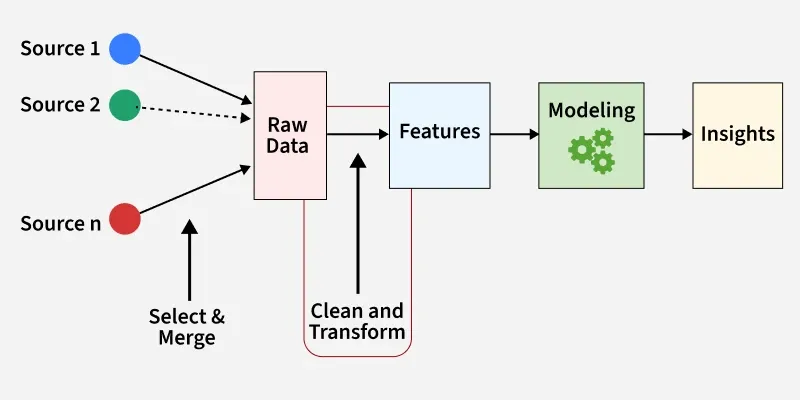

ref: https://www.geeksforgeeks.org/machine-learning/what-is-feature-engineering/



---


# **Outline for Feature Engineering**
### **1. Feature Transformation**
### **2. Feature Selection**
### **3. Dimensionaliy Reduction**
### **4. Imbalanced Data**

📖🤜

---

# **1. Featrue Transformation**

### **Feature Transformation คือการแปลงค่าของ features (ตัวแปร) ให้อยู่ในรูปแบบที่เหมาะสมกับการเรียนรู้ของโมเดล**

คือการปรับรูปร่างข้อมูล เพื่อให้โมเดล ML เข้าใจและเรียนรู้ได้ง่ายขึ้น เช่น
* ทำให้ข้อมูลอยู่ในสเกลใกล้เคียงกัน
* แปลงข้อมูลที่เบ้ (skewed) ให้มีการกระจายดีขึ้น
* แปลงข้อมูลเชิงหมวดหมู่ให้เป็นตัวเลขที่โมเดลเข้าใจได้


---


### **Feature Transformation is tranformaing features to be the new form that ML can learn better**

example:
* tranform data that originally be in different scale like (150 to 215 cm.), (40 to 120 kg), tranfrom into same scale like (0 to 1) etc.
* tranform skewed data to be less skewed
* tranform feature that represent category by text into number so ML can understand e.g. Category (bird, cat, dog, tiger) -> (0, 1, 2, 3)
---

### 🔧 **ทำไมต้องทำ Feature Transformation**

เพราะ **โมเดลส่วนใหญ่ (เช่น Linear Regression, SVM, Neural Network) มีสมมติฐานว่า**

* ข้อมูลต้องมี ***สเกลที่ใกล้เคียงกัน***

* ไม่มีค่า outlier มากเกินไป

* ความสัมพันธ์ระหว่าง feature กับผลลัพธ์ควรเป็นเชิงเส้น (linear)

ดังนั้น การแปลงข้อมูลจึงช่วยให้:

* โมเดลเรียนรู้ได้เร็วขึ้น (gradient descent จะเสถียรกว่า)

* ลดผลกระทบของ outlier

* ทำให้ข้อมูลเหมาะกับสมมติฐานของโมเด


---


### 🔧 **Why we need Feature Transformation**

since **Most ML model (e.g. Linear Regression, SVM, Neural Network) assume that**
* feature shold be in the same scale
* outlier data not exits too much
* relation between each feature -- target should be in linear way

so Feature Transformation help
* ML model learn with feature in faster rate (gradient descent will be more stable)
* decrese effects of outlier data
* make data allign with assumption or requirment of the ML model


In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    Normalizer,
    OneHotEncoder,
    LabelEncoder,
    PowerTransformer,
    KBinsDiscretizer
)

## **Iris Dataset**
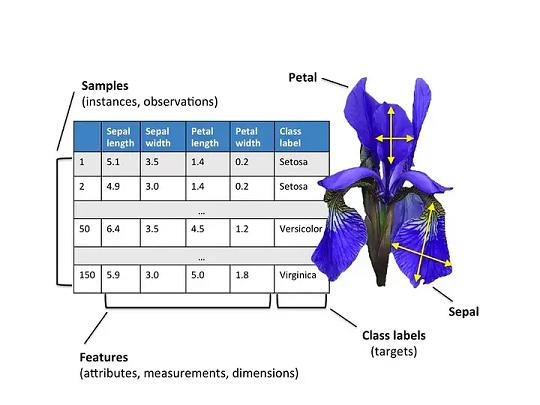

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['color'] = ['red', 'blue', 'green'] * 50  # Add a categorical feature

print("Original Data (first 5 rows):")
print(df.head())

Original Data (first 5 rows):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  color  
0       0    red  
1       0   blue  
2       0  green  
3       0    red  
4       0   blue  


##plot histogram for every features in Dataset for observing scale and distribution of each feature


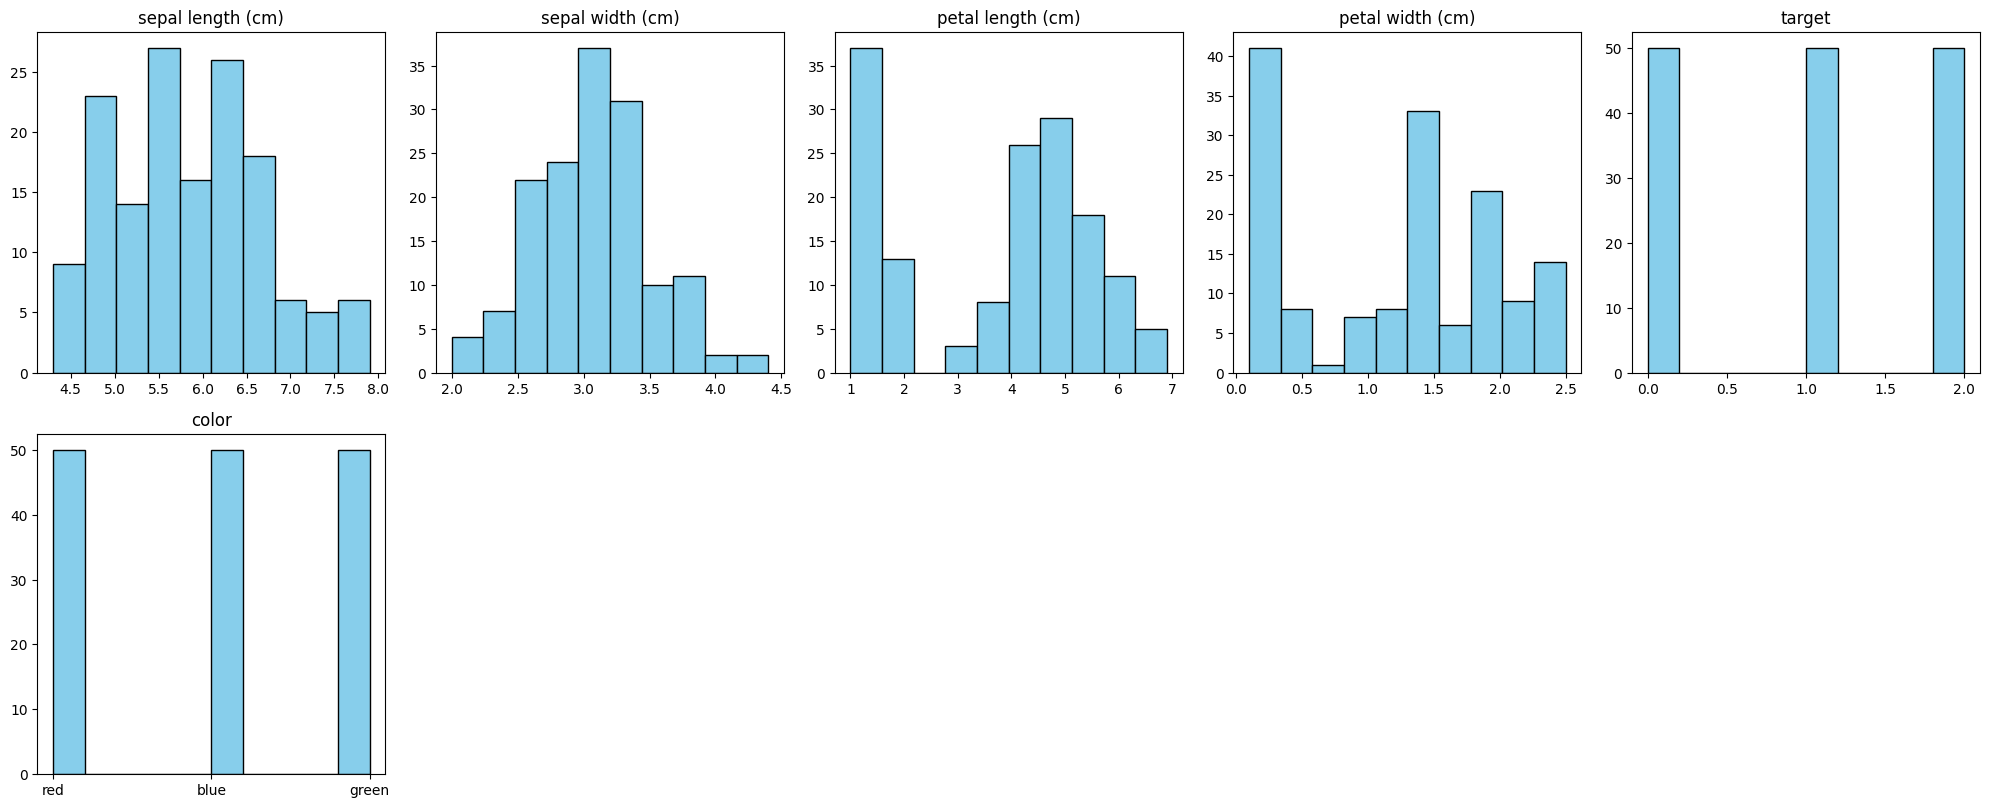

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))

for i, col in enumerate(df.columns):
    plt.subplot(5, 5, i + 1)
    plt.hist(df[col], color='skyblue', edgecolor='black')
    plt.title(col)
    plt.tight_layout()

plt.show()

we can notice that ...
1. feature sepal length, data in scale length 4.5 - 8.0 cm.
2. feature sepal width, data in scale length 2 - 4.5 cm.
3. feature petal length,data in scale length  1 - 7 cm.
4. feature petal width, data in scale length 0 - 2.5 cm.
5. feature target or specie of flower, it is the feature that we want Model to predict this value, the value is quantitative value not qualitative value. each number represent each species of flower 0 (setosa) , 1 (versicolor), 2 (virginica)
6. feature color is also quantitative value  red, blue, green

## 1.1 Scaling: MinMax and Standardization
**MinMax:** เป็นวิธีการปรับขนาดของข้อมูลให้อยู่ในช่วงที่กำหนด ซึ่งโดยทั่วไปมักจะปรับขนาดของข้อมูลให้อยุ่ในช่วง 0-1 ค่าที่มากที่สุด จะถูกปรับค่าเป็น 1 ส่วนค่าอื่นๆก็จะถูกปรับให้น้อยลงมาเรื่อยๆ จนถึง ค่าที่น้อยที่สุด จะถูกปรับค่าเป็น 0

**Standardization** หรือ Z-Score Normalization เป็นเทคนิคที่ปรับขนาดข้อมูลให้มีการแจกแจง หรือมีการกระจายตัว แบบปกติ (Normal Distribution) x=(x-mean)/stad..

---


## 1.1 Scaling: MinMax and Standardization
**MinMax:** is changing the feature's value to be in some specific range, typically range is 0 to 1, by the max value will be changed to 1 and the min value will be changed to 0

**Standardization** หรือ Z-Score Normalization is technique that change feature' value to be the form of Z-value with mean value = 0 and STD (standard daviation) = 1  (Normal Distribution) x=(x-mean)/stad..

In [ ]:
scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()

scaled_minmax = scaler_minmax.fit_transform(df[['sepal length (cm)', 'sepal width (cm)']])
scaled_standard = scaler_standard.fit_transform(df[['sepal length (cm)', 'sepal width (cm)']])

print("MinMax Scaled (0-1 range):\n", scaled_minmax[:5], "\n")
print("Standardized (mean=0, std=1):\n", scaled_standard[:5], "\n")

MinMax Scaled (0-1 range):
 [[0.22222222 0.625     ]
 [0.16666667 0.41666667]
 [0.11111111 0.5       ]
 [0.08333333 0.45833333]
 [0.19444444 0.66666667]] 

Standardized (mean=0, std=1):
 [[-0.90068117  1.01900435]
 [-1.14301691 -0.13197948]
 [-1.38535265  0.32841405]
 [-1.50652052  0.09821729]
 [-1.02184904  1.24920112]] 



In [ ]:
# @title MinMax From Scratch
import numpy as np

X = np.array([10, 12, 14, 20, 30], dtype=float)

X_min = X.min()
X_max = X.max()

X_norm = (X - X_min) / (X_max - X_min)
X_norm


array([0. , 0.1, 0.2, 0.5, 1. ])

In [ ]:
# @title Standardization (Z-score) From scratch

X = np.array([10, 12, 14, 20, 30], dtype=float)
X_2d = X.reshape(-1, 1)


mu = X.mean()
sigma = X.std()
X_std_manual = (X - mu) / sigma
print(X_std_manual)

[-0.9969278  -0.72000341 -0.44307902  0.38769414  1.77231608]


## 1.2  L2 normalization
ทำการปรับขนาดเวกเตอร์ v(ซึ่งอาจเป็นแถวของฟีเจอร์ในชุดข้อมูล หรือเวกเตอร์น้ำหนักในโมเดล) ให้เป็น v′ โดยการหารทุกองค์ประกอบของเวกเตอร์นั้นด้วย ความยาว (Length) ของเวกเตอร์เดิม ซึ่งคำนวณได้จาก L2-norm


---



changing the magnitude of vector v (v might be the data of 1 row that contain many features) to be v' . transform vector's magnitude by dividing with its own length or norm (can calculate from L2-norm)

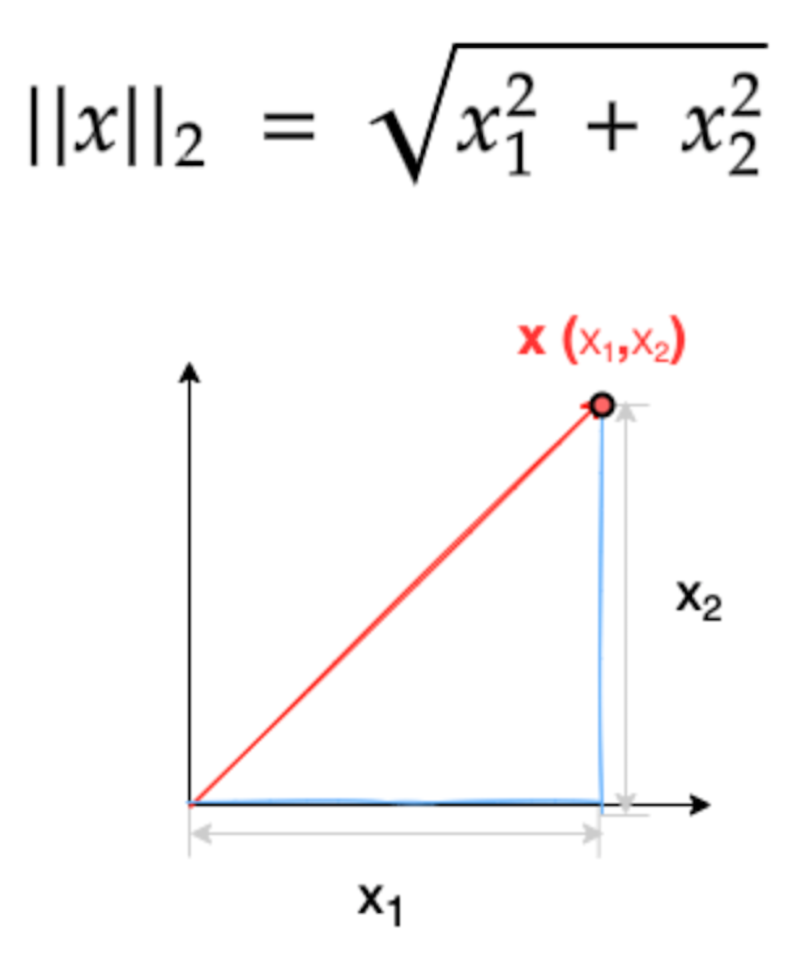

In [ ]:
normalizer = Normalizer(norm='l2')
normalized = normalizer.fit_transform(df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)']])
print("Normalized Feature (L2 norm=2):\n", normalized[:5], "\n")

Normalized Feature (L2 norm=2):
 [[0.80417236 0.55188299 0.2207532 ]
 [0.82860636 0.50731002 0.23674468]
 [0.80580638 0.54863413 0.22288262]
 [0.80051467 0.53947728 0.26103739]
 [0.79136117 0.56978004 0.22158113]] 



## 1.3 Encoding: Categorical -> Numeric

## Label Encode
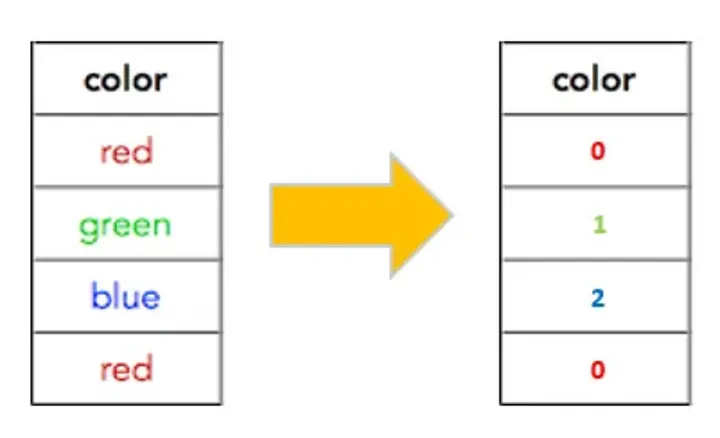

ref: https://medium.com/@sunnykumar1516/what-is-label-encoding-application-of-label-encoder-in-machine-learning-and-deep-learning-models-c593669483ed

## Noe-Hot Encode
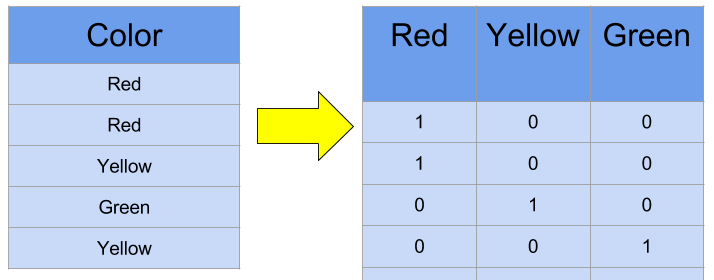

ref: https://www.kaggle.com/code/dansbecker/using-categorical-data-with-one-hot-encoding


In [ ]:
# --- Label Encoding ---
label_encoder = LabelEncoder()
df['color_encode'] = label_encoder.fit_transform(df['color'])
print("===Label Encoded: \n", df[['color', 'color_encode']].head(), "\n")

# --- One-Hot Encoding ---
onehot_encoder = OneHotEncoder(sparse_output=False)
onehot = onehot_encoder.fit_transform(df[['color']])
onehot_df = pd.DataFrame(onehot, columns=onehot_encoder.get_feature_names_out(['color']))
print("===One-Hot Encoded:\n", onehot_df.head(), "\n")


===Label Encoded: 
    color  color_encode
0    red             2
1   blue             0
2  green             1
3    red             2
4   blue             0 

===One-Hot Encoded:
    color_blue  color_green  color_red
0         0.0          0.0        1.0
1         1.0          0.0        0.0
2         0.0          1.0        0.0
3         0.0          0.0        1.0
4         1.0          0.0        0.0 



## 1.4 Log / Power Transformation

**log / Power Transformation can fix the skewed data to be more normally distribution.**    

---



example of Power Transformation

method:

yeo-johson (handles positive and negative data, and zeros)

box-cox (requires positive data)

**These methods will calculate the perfect $\lambda$ value for change the data, automatically**

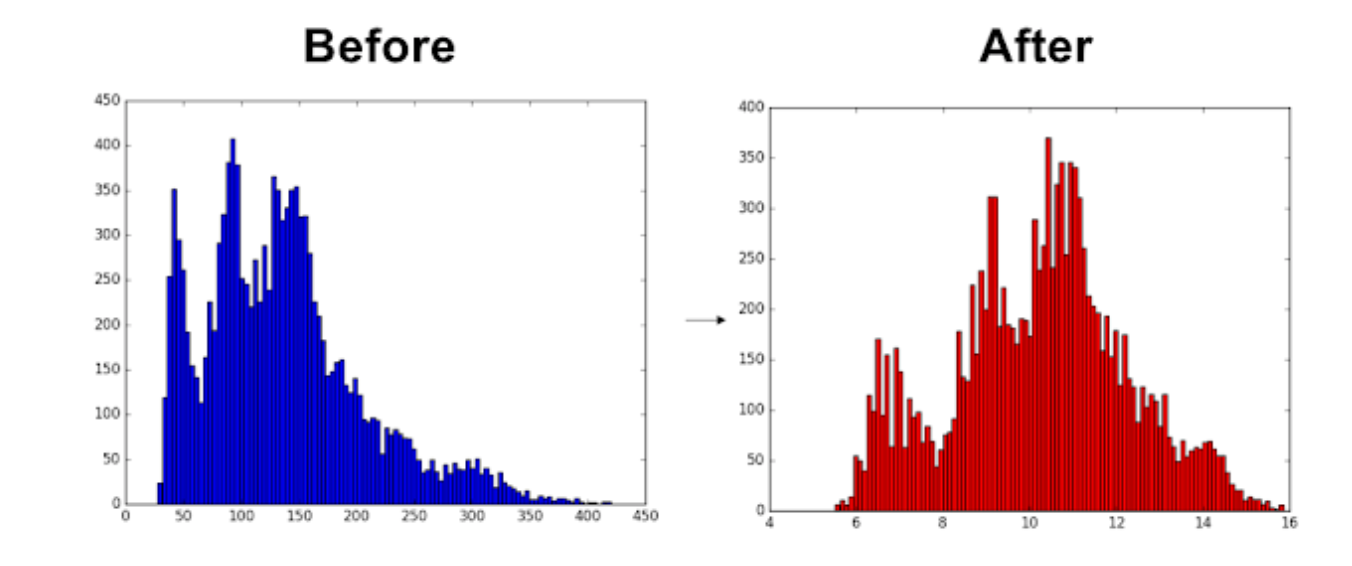

In [4]:
pt = PowerTransformer(method="yeo-johnson")
transformed_yeo = pt.fit_transform(df[['sepal length (cm)', 'sepal width (cm)']])
print("Power Transformed (Yeo-Johnson):\n", transformed_yeo[:5])

Power Transformed (Yeo-Johnson):
 [[-0.89568956  1.02290812]
 [-1.18517298 -0.08191726]
 [-1.48792061  0.37512614]
 [-1.64460909  0.14928267]
 [-1.03883758  1.22963766]]


In [3]:
pt = PowerTransformer(method="box-cox")
transformed_box = pt.fit_transform(df[['sepal length (cm)', 'sepal width (cm)']])
print("Power Transformed (Box-cox):\n", transformed_box[:5])

Power Transformed (Box-cox):
 [[-0.8947422   1.02172936]
 [-1.1851801  -0.08194651]
 [-1.48951683  0.37432032]
 [-1.64729682  0.14883298]
 [-1.03829865  1.22864298]]


Text(0.5, 1.0, 'power-box-cox')

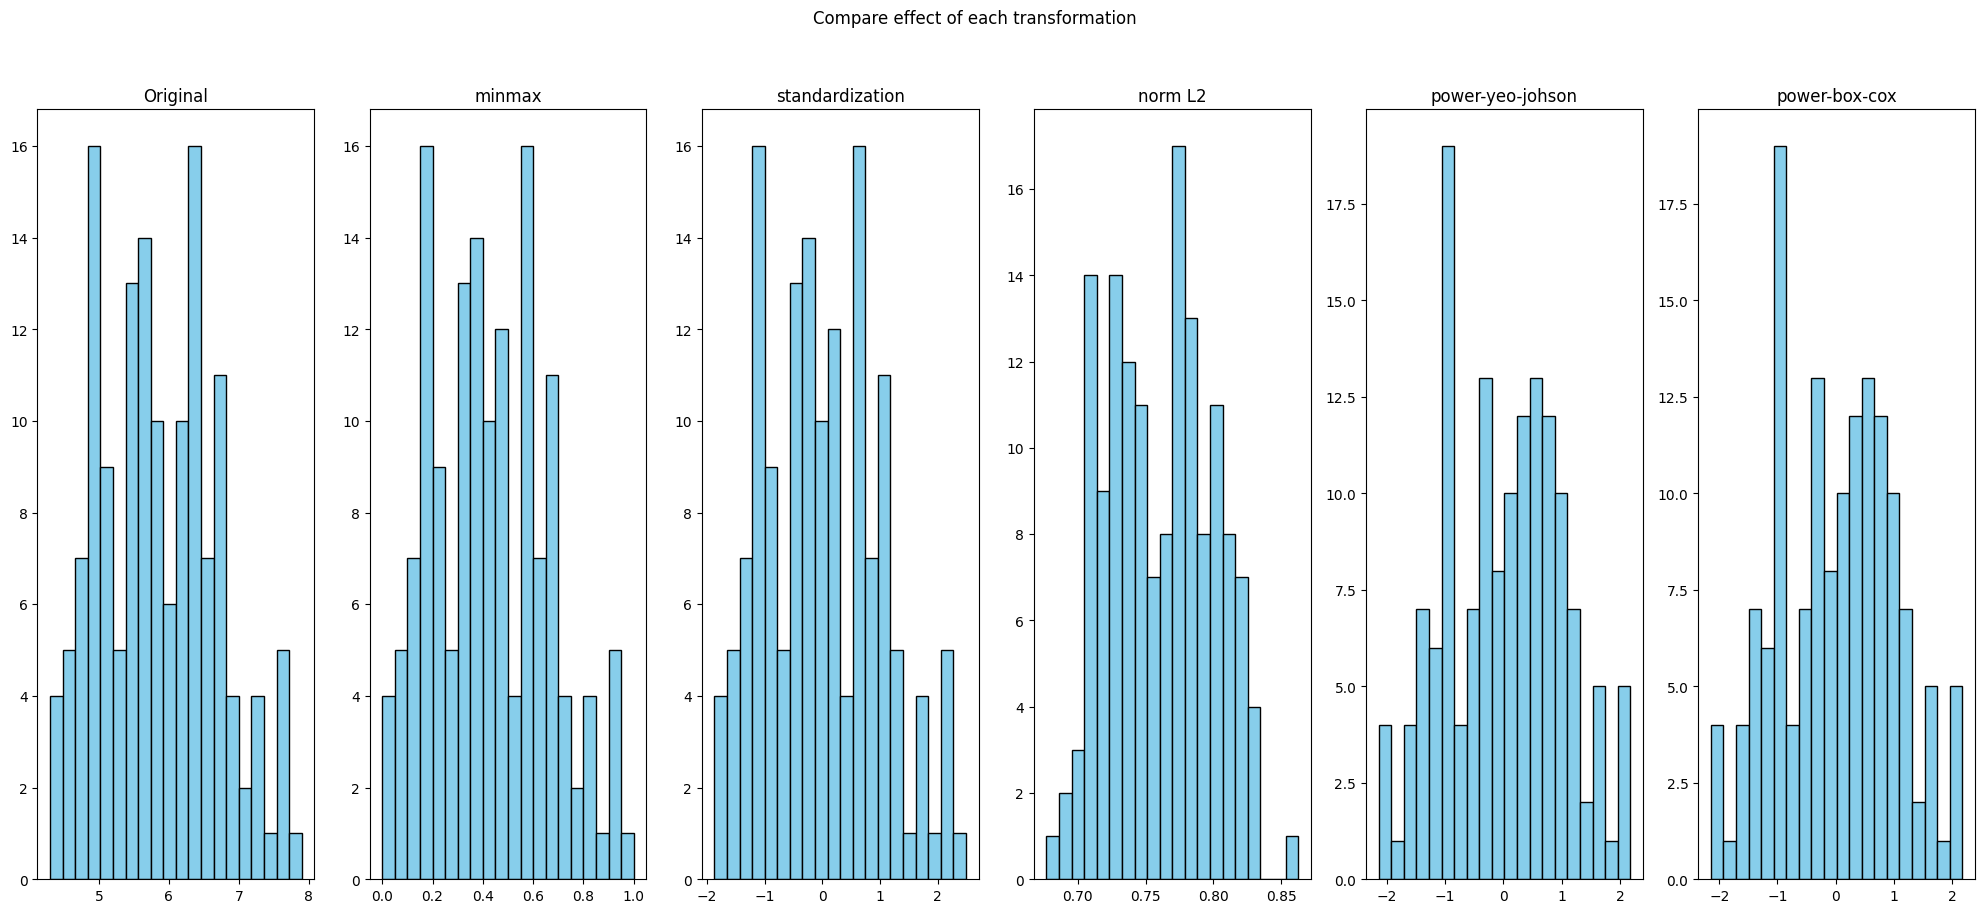

In [ ]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(nrows=1, ncols=6, figsize=(25, 10))

fig.suptitle("Compare effect of each transformation")

ax[0].hist(df['sepal length (cm)'], color='skyblue', edgecolor='black', bins=20)
ax[0].set_title("Original")

ax[1].hist(scaled_minmax[:, 0], color='skyblue', edgecolor='black', bins=20)
ax[1].set_title("minmax")

ax[2].hist(scaled_standard[:, 0], color='skyblue', edgecolor='black', bins=20)
ax[2].set_title("standardization")

ax[3].hist(normalized[:, 0], color='skyblue', edgecolor='black', bins=20)
ax[3].set_title("norm L2")

ax[4].hist(transformed_yeo[:, 0], color='skyblue', edgecolor='black', bins=20)
ax[4].set_title("power-yeo-johson")

ax[5].hist(transformed_box[:, 0], color='skyblue', edgecolor='black', bins=20)
ax[5].set_title("power-box-cox")


In [ ]:
# @title Optional: petal length-width (box-cox)

pt = PowerTransformer(method="box-cox")
transformed = pt.fit_transform(df[['petal length (cm)', 'petal width (cm)']])
print("Power Transformed (Yeo-Johnson):\n", transformed[:5])

Power Transformed (Yeo-Johnson):
 [[-1.34765665 -1.38971626]
 [-1.34765665 -1.38971626]
 [-1.408043   -1.38971626]
 [-1.28756623 -1.38971626]
 [-1.34765665 -1.38971626]]


## 1.5 Binning
##Split sepal length into 3 groups: small medium large


In [ ]:
binner = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
binned = binner.fit_transform(df[['sepal length (cm)']])
df['sepal_length_bin'] = binned.astype(int)

print("Binned Sepal Length:\n\n", df[['sepal length (cm)', 'sepal_length_bin']].head(10), "\n")

Binned Sepal Length:

    sepal length (cm)  sepal_length_bin
0                5.1                 0
1                4.9                 0
2                4.7                 0
3                4.6                 0
4                5.0                 0
5                5.4                 0
6                4.6                 0
7                5.0                 0
8                4.4                 0
9                4.9                 0 



### Bining with own range based condition

In [ ]:
import pandas as pd

bins = [0, 3.5, 5, 6, 10]
labels = ['tiny petal', 'normal petal', 'large petal', 'super large peral']

df['size petal'] = pd.cut(df['petal length (cm)'], bins=bins, labels=labels, right=False)

print(df)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target  color  sepal_l

## 1.6 Combine transformed features

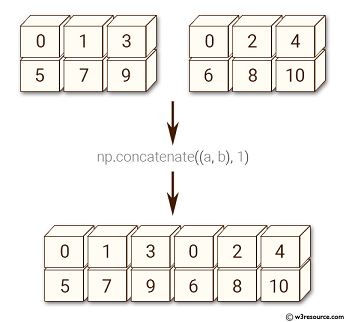

In [ ]:
final_df = pd.concat([df, onehot_df], axis=1)
print("Final DataFrame with all transfromaitons ")
final_df

Final DataFrame with all transfromaitons 


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,color,sepal_length_bin,size petal,color_encode,area petal (cm)^2,color_blue,color_green,color_red
0,5.1,3.5,1.4,0.2,0,red,0,tiny petal,2,0.28,0.0,0.0,1.0
1,4.9,3.0,1.4,0.2,0,blue,0,tiny petal,0,0.28,1.0,0.0,0.0
2,4.7,3.2,1.3,0.2,0,green,0,tiny petal,1,0.26,0.0,1.0,0.0
3,4.6,3.1,1.5,0.2,0,red,0,tiny petal,2,0.30,0.0,0.0,1.0
4,5.0,3.6,1.4,0.2,0,blue,0,tiny petal,0,0.28,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,blue,2,large petal,0,11.96,1.0,0.0,0.0
146,6.3,2.5,5.0,1.9,2,green,1,large petal,1,9.50,0.0,1.0,0.0
147,6.5,3.0,5.2,2.0,2,red,1,large petal,2,10.40,0.0,0.0,1.0
148,6.2,3.4,5.4,2.3,2,blue,1,large petal,0,12.42,1.0,0.0,0.0


##1.7 Create new feature from mathematic operations

### example:: create new feature, it is "area of petal (cm^2)", making by bring feature "petal length (cm)" multiply by "petal width (cm)".  
!!please be careful of "unit" in each feature, maybe they are not in the same unit e.g. feature length (cm.) but another feature width is (mm.) so you need to transform unit before do math operatin!!

In [ ]:
df['area petal (cm)^2'] = df['petal length (cm)'] * df['petal width (cm)']
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,color,sepal_length_bin,size petal,color_encode,area petal (cm)^2
0,5.1,3.5,1.4,0.2,0,red,0,tiny petal,2,0.28
1,4.9,3.0,1.4,0.2,0,blue,0,tiny petal,0,0.28
2,4.7,3.2,1.3,0.2,0,green,0,tiny petal,1,0.26
3,4.6,3.1,1.5,0.2,0,red,0,tiny petal,2,0.30
4,5.0,3.6,1.4,0.2,0,blue,0,tiny petal,0,0.28
...,...,...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,blue,2,large petal,0,11.96
146,6.3,2.5,5.0,1.9,2,green,1,large petal,1,9.50
147,6.5,3.0,5.2,2.0,2,red,1,large petal,2,10.40
148,6.2,3.4,5.4,2.3,2,blue,1,large petal,0,12.42


##1.8 Handle with missing Data

### Create Dataset which contain missing data

In [ ]:
import pandas as pd
import numpy as np

data = {
    'School ID': [101, 102, 103, np.nan, 105, 106, 107, 108],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank', 'Grace', 'Henry'],
    'Address': ['123 Main St', '456 Oak Ave', '789 Pine Ln', '101 Elm St', np.nan, '222 Maple Rd', '444 Cedar Blvd', '555 Birch Dr'],
    'City': ['Los Angeles', 'New York', 'Houston', 'Los Angeles', 'Miami', np.nan, 'Houston', 'New York'],
    'Subject': ['Math', 'English', 'Science', 'Math', 'History', 'Math', 'Science', 'English'],
    'Marks': [85, 92, 78, 89, np.nan, 95, 80, 88],
    'Rank': [2, 1, 4, 3, 8, 1, 5, 3],
    'Grade': ['B', 'A', 'C', 'B', 'D', 'A', 'C', 'B']
}

df = pd.DataFrame(data)
print("Sample DataFrame:")

print(df)

Sample DataFrame:
   School ID     Name         Address         City  Subject  Marks  Rank Grade
0      101.0    Alice     123 Main St  Los Angeles     Math   85.0     2     B
1      102.0      Bob     456 Oak Ave     New York  English   92.0     1     A
2      103.0  Charlie     789 Pine Ln      Houston  Science   78.0     4     C
3        NaN    David      101 Elm St  Los Angeles     Math   89.0     3     B
4      105.0      Eva             NaN        Miami  History    NaN     8     D
5      106.0    Frank    222 Maple Rd          NaN     Math   95.0     1     A
6      107.0    Grace  444 Cedar Blvd      Houston  Science   80.0     5     C
7      108.0    Henry    555 Birch Dr     New York  English   88.0     3     B


### Remove rows that missing data

In [ ]:
df_cleaned = df.dropna()

print("\nDataFrame after removing rows with missing values:")
print(df_cleaned)


DataFrame after removing rows with missing values:
   School ID     Name         Address         City  Subject  Marks  Rank Grade
0      101.0    Alice     123 Main St  Los Angeles     Math   85.0     2     B
1      102.0      Bob     456 Oak Ave     New York  English   92.0     1     A
2      103.0  Charlie     789 Pine Ln      Houston  Science   78.0     4     C
6      107.0    Grace  444 Cedar Blvd      Houston  Science   80.0     5     C
7      108.0    Henry    555 Birch Dr     New York  English   88.0     3     B


### Imputation Methods (Filling value instead of delete row)

#### 1. Adding missing values by using **MEAN** value

In [ ]:
add_mean = df['Marks'].fillna(df['Marks'].mean())
print(add_mean)

0    85.000000
1    92.000000
2    78.000000
3    89.000000
4    86.714286
5    95.000000
6    80.000000
7    88.000000
Name: Marks, dtype: float64


#### 2. Adding missing values by using **MEDIAN** value

In [ ]:
add_medion = df['Marks'].fillna(df['Marks'].median())
print(add_medion)

0    85.0
1    92.0
2    78.0
3    89.0
4    88.0
5    95.0
6    80.0
7    88.0
Name: Marks, dtype: float64


#### 3. Adding missing values by using **MODE** value.

In [ ]:
add_mode = df['Marks'].fillna(df['Marks'].mode().iloc[0])
print(add_mode)

0    85.0
1    92.0
2    78.0
3    89.0
4    78.0
5    95.0
6    80.0
7    88.0
Name: Marks, dtype: float64


#### 4.Adding missing values by using **FORWARD FILLING** (using the previous value).

In [ ]:
forward_fill = df['Marks'].fillna(method='ffill')
print("\nForward Fill:")
print(forward_fill)


Forward Fill:
0    85.0
1    92.0
2    78.0
3    89.0
4    89.0
5    95.0
6    80.0
7    88.0
Name: Marks, dtype: float64


/tmp/ipython-input-1241147156.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  forward_fill = df['Marks'].fillna(method='ffill')


#### 5.Adding missing values by using **BACKWARD FILLING** (using the later value).

In [ ]:
backward_fill = df['Marks'].fillna(method='bfill')
print("\nBackward Fill:")
print(backward_fill)


Backward Fill:
0    85.0
1    92.0
2    78.0
3    89.0
4    95.0
5    95.0
6    80.0
7    88.0
Name: Marks, dtype: float64


/tmp/ipython-input-4204234439.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  backward_fill = df['Marks'].fillna(method='bfill')


#### 6.Adding missing values by using **LINEAR INTERPOLATION** (calculate by using neighbor values).

In [ ]:
add_linear = df['Marks'].interpolate(method='linear')
print("\nLinear Interpolation:")
print(add_linear)


Linear Interpolation:
0    85.0
1    92.0
2    78.0
3    89.0
4    92.0
5    95.0
6    80.0
7    88.0
Name: Marks, dtype: float64


#### 7.Adding missing values by using **QUADRATIC INTERPOLATION** (calculate by using neighbor values).

In [ ]:
add_quad = df['Marks'].interpolate(method='quadratic')
print("\nQuadratic Interpolation:")
print(add_quad)


Quadratic Interpolation:
0    85.00000
1    92.00000
2    78.00000
3    89.00000
4    98.28024
5    95.00000
6    80.00000
7    88.00000
Name: Marks, dtype: float64


### Removing outlier data (data that value is far away from main group) by using IQR (Inter Quartile Range)

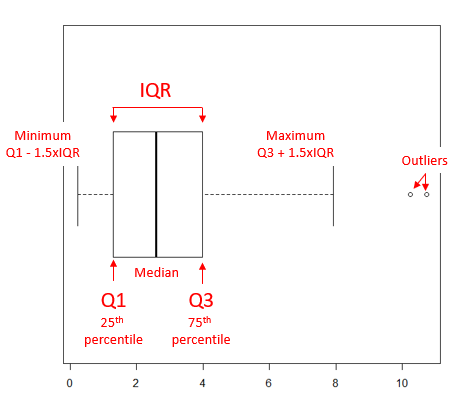

(0.0, 80.0)

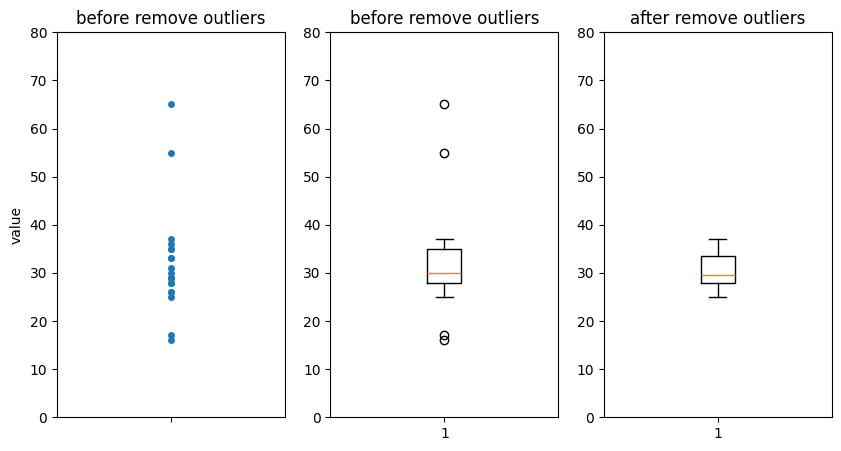

In [ ]:
import sklearn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# mock data
data = [29, 16, 35, 26, 65, 28, 17, 33, 36, 55, 29, 25, 30, 85, 33, 29, 35, 31, 26, 28, 37]
df = pd.DataFrame(data, columns=['value'])


# initial ploting
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))

sns.stripplot(y=df['value'], ax=ax[0], jitter=False)
ax[0].set_title("before remove outliers")
ax[0].set_ylim(0, 80)

ax[1].boxplot(df['value'])
ax[1].set_title("before remove outliers")
ax[1].set_ylim(0, 80)


#------------------------------- REMOVE  Outliers --------------------------------
q1 = df['value'].quantile(0.25)
q3 = df['value'].quantile(0.75)
IQR = q3 - q1
lower = q1 - 1.5*IQR
upper = q3 + 1.5*IQR

upper_array = np.where(data >= upper)[0]
lower_array = np.where(data <= lower)[0]

df.drop(index=upper_array, inplace=True)
df.drop(index=lower_array, inplace=True)
#------------------------------- REMOVE  Outliers --------------------------------

ax[2].boxplot(df['value'])
ax[2].set_title("after remove outliers")
ax[2].set_ylim(0, 80)


# **2. Feature Selection**
## คือกระบวนการเลือกเฉพาะ features ที่มีความสำคัญต่อการทำนายผลลัพธ์ (target) ***โดยตัดทิ้ง features*** **ที่ไม่เกี่ยวข้อง, ซ้ำซ้อน หรือมี noise ออกไป**


---


# **2. Feature Selection**
## Process of selecting only some features that important to target feature  **remove any unrelated, similar or noise data**


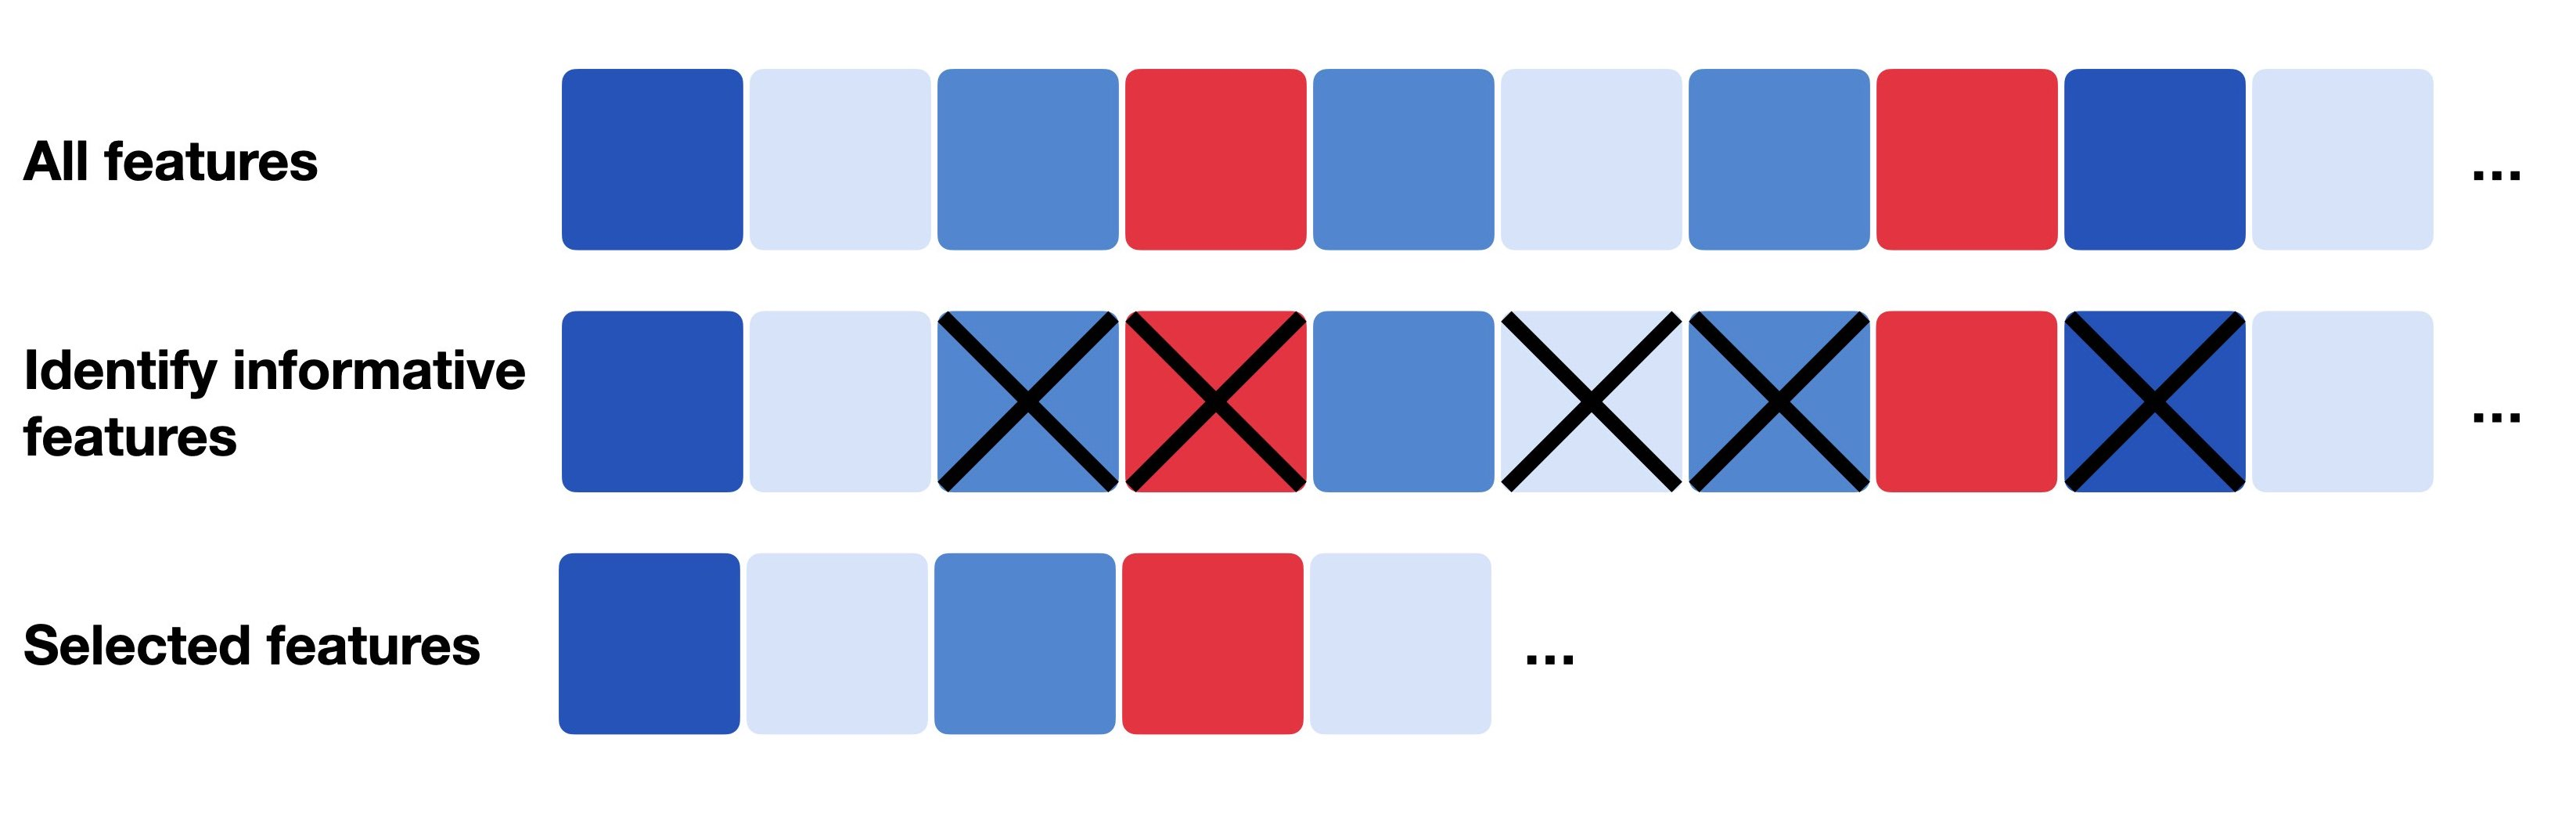

Ref:https://www.sc-best-practices.org/preprocessing_visualization/feature_selection.html
---
##Why Feature Selection is important?

1. increse effciency of Models
2. reduce overfitting
3. make ML more interpretability (understanding which feature is actual important for target)
4. reduce training trime and memory usage




#  Feature Selection Example

1️⃣ **Filter Methods**	ใช้สถิติวัดความสัมพันธ์ระหว่าง feature กับ target	Correlation, Chi-square, ANOVA

2️⃣ **Wrapper Methods** ใช้โมเดลในการเลือก feature ที่ให้ผลดีที่สุด	Forward/Backward selection, RFE

3️⃣ **Embedded Methods**	ให้โมเดลเลือก feature ระหว่างการ train เอง	Lasso Regression, Tree-based importance


---



1️⃣ **Filter Methods**	using statistical value to messure how strong of relation between feature and target e.g.	Persons' Correlation, Chi-square, ANOVA

2️⃣ **Wrapper Methods** using model to choose some set of features that give the best result, e.g.	Forward/Backward selection, RFE

3️⃣ **Embedded Methods**	using model to choose features while training period, e.g. Lasso Regression, Tree-based importance



In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import (SelectKBest, chi2, f_classif, RFE)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Load Dataset ⌛

In [ ]:
data = load_breast_cancer()
x = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
print("Original feature count :", x.shape[1], "\n Column name:",list(x.columns[:5]), "...")

Original feature count : 30 
 Column name: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness'] ...


## 2.1 Filter method
---
### 2.1.1. SelectKBest ▶ using statistical value such as chi-square, AOVA F-test
Exp: choosing only top 5 features

---

In [ ]:
selector_filter = SelectKBest(score_func=f_classif, k=5)
x_selected_filter = selector_filter.fit_transform(x, y)
selected_features_filter = x.columns[selector_filter.get_support()]

print("Filter Method (ANOVA F-test)")
print("Selected featrues:", list(selected_features_filter))

Filter Method (ANOVA F-test)
Selected featrues: ['mean perimeter', 'mean concave points', 'worst radius', 'worst perimeter', 'worst concave points']


### 2.1.2 Pearson's Correlation
Person's Correlation value state how strong the relation between pair of features in linearly   
    if R is + (near 1) means both feaure have strong linear relation in the same direction.   
    if R is - (near -1) mean both features have strong linear relation in the opposite direction.   
    if R is near 0 mean both features have weak linear relation.   

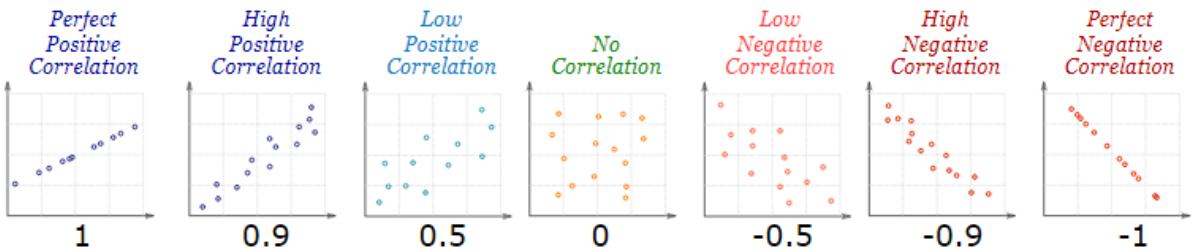

#### Pearson's R From Scratch

In [ ]:
import numpy as np

np.random.seed(42)
x = np.random.randn(100)
y = 2 * x + np.random.randn(100) * 0.5  # Add Noise

def pearson_r(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    x_mean = x.mean()
    y_mean = y.mean()
    num = ((x - x_mean) * (y - y_mean)).sum()
    den = np.sqrt(((x - x_mean) ** 2).sum() * ((y - y_mean) ** 2).sum())
    return num / den

r_manual = pearson_r(x, y)
print("Pearson's r (manual) =", r_manual)


Pearson's r (manual) = 0.9654943669720486


#### Pearson’s R – ใช้ numpy / pandas / scipy

In [ ]:

import scipy.stats as stats
import pandas as pd

# numpy
r_np = np.corrcoef(x, y)[0, 1]
print("Pearson's r (numpy) =", r_np)

# pandas
df = pd.DataFrame({"x": x, "y": y})
print(df.corr())  # default คือ Pearson

# scipy + p-value
r_scipy, p_value = stats.pearsonr(x, y)
print("Pearson's r (scipy) =", r_scipy, "p-value =", p_value)


Pearson's r (numpy) = 0.9654943669720483
          x         y
x  1.000000  0.965494
y  0.965494  1.000000
Pearson's r (scipy) = 0.9654943669720488 p-value = 4.538186359602375e-59


## 2.2 Wrapper Method
---
### Recursive feature elimination  ▶ Method that "Model choose features"

---


In [ ]:
model_lr = LogisticRegression(max_iter=500)
selector_rfe = RFE(model_lr, n_features_to_select=5)
x_selected_rfe = selector_rfe.fit_transform(x, y)
selected_features_rfe = x.columns[selector_rfe.get_support()]

print("\n Wrapper method (RFE withd logistic Regression)")
print("Selected features:", list(selected_features_rfe))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


 Wrapper method (RFE withd logistic Regression)
Selected features: ['mean radius', 'texture error', 'worst radius', 'worst compactness', 'worst concavity']


# 2.3 Embedded Method
---

## 2.3.1 Tree-based model ▶ using  feature importances from Tree

choose feature by determing how it important to Model

---

In [ ]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(x,y)
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]

selected_features_embedded = x.columns[indices[:5]]

print("Embedded Model: Tree-besed importence")
print("Select feature:", list(selected_features_embedded))

Embedded Model: Tree-besed importence
Select feature: ['worst area', 'worst concave points', 'mean concave points', 'worst radius', 'worst perimeter']


## Summarize & compare Features from 3 different methods
🔉👍

---

In [ ]:
summary = pd.DataFrame(
    {
        "Filter (F-test)" : list(selected_features_filter),
        "Wrapper (RFE)" : list(selected_features_rfe),
        "Embedded (RF Importacne)" : list(selected_features_embedded)
    }
)
print("Comparison of top 5 features from each mothod:")
print(summary)

Comparison of top 5 features from each mothod:
        Filter (F-test)      Wrapper (RFE) Embedded (RF Importacne)
0        mean perimeter        mean radius               worst area
1   mean concave points      texture error     worst concave points
2          worst radius       worst radius      mean concave points
3       worst perimeter  worst compactness             worst radius
4  worst concave points    worst concavity          worst perimeter



# **สรุปจุดเด่นของวิธีการแลือก feature แต่ละแบบ**
## **Filter** 👍*ข้อดี* 👌 เร็ว, ใช้ง่าย, ไม่ต้อง train model >> ❌*ข้อเสีย* 🙅  ไม่คำนึงถึงความสัมพันธ์ระหว่าง features
## **Warpper** 👍*ข้อดี* 👌 แม่นกว่า, พิจารณา interactions >> ❌*ข้อเสีย* 🙅 ช้า, ใช้เวลามาก, เสี่ยง overfitting
## **Embedded** 👍*ข้อดี* 👌 มีสมดุลระหว่างความเร็วและความแม่น >> ❌*ข้อเสีย* 🙅 ต้องใช้โมเดลที่สนับสนุน feature importance เช่น Tree


---


# **Summary pros & cons of each fearue selection**
## **Filter** 👍*pros* 👌 fast, easy to use, don't need to train model >> ❌*cons* 🙅  don't care about relation between each feature (care only feature-target)  
## **Warpper** 👍*pros* 👌 more precisely, giving important to interactions >> ❌*cons* 🙅 more slow, take much time to train, can happen overfitting
## **Embedded** 👍*pros* 👌 balance between fast and precisely >> ❌*cons* 🙅 using another model to determine how important of each fature e.g. tree model

---

choose wisely

---

---
# **3. Dimensionaliy Reduction**
Dimensionality Reduction คือ กระบวนการ **ลดจำนวน feature (มิติ)** ของข้อมูลลง
โดยพยายาม **รักษาข้อมูลสำคัญ (important information)** ไว้ให้ได้มากที่สุด



---



Dimensionality Reduction is a process that try to reduce the original dimensions (amount of features) into a new set of dimensions that have fewer dimensions. the concept is when we reduce dimension, we will surely lose some of information, so the new dimensions that we choose must to stil maintain most of all information.


---



in the following figure, [left image] you will see that originally our data have 3 dimesnions (or 3 features : feature x, y, z)     
     
[middle image] we change our dataset into 2 new dimensions instead of x,y,z dimension. (the new dimensions are not x, y  maybe you can named it u, v)     
     
[right image] we continue change our dataset into a new deminsion instead of 2 dimensions. so now our dataset have only 1 dimesnion (or 1 feature)   
       



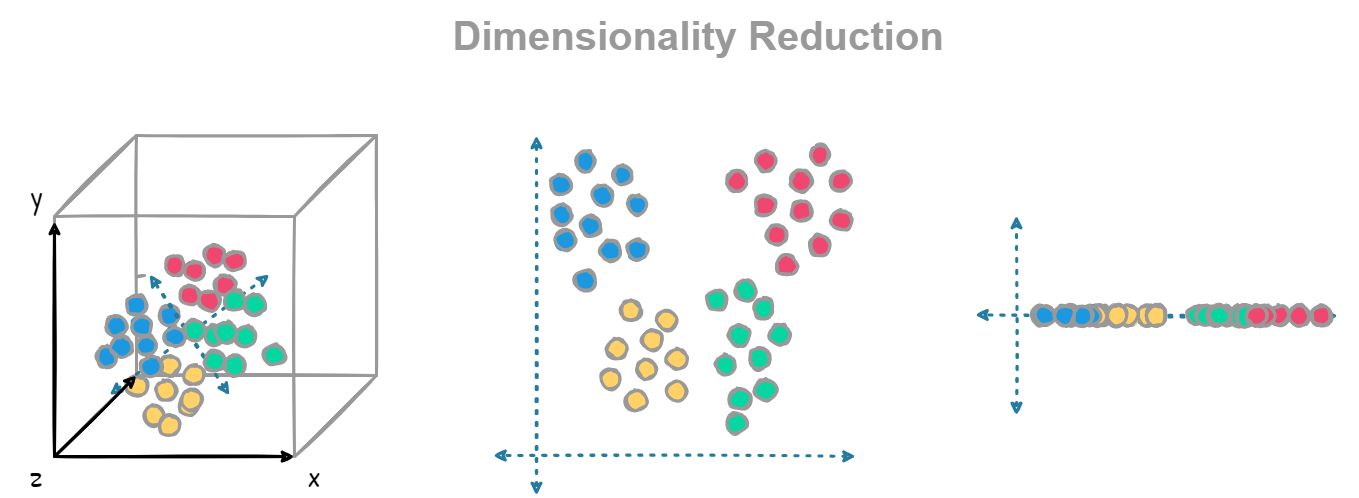

## ทำไมต้องลดมิติ ❓
เมื่อข้อมูลมี จำนวน feature เยอะมาก (เช่น หลายร้อยหรือหลายพันตัวแปร) จะเกิดปัญหา:

* **โมเดลเรียนรู้ยาก** (curse of dimensionality)
* **เวลา train นาน**, กินหน่วยความจำ
* **ข้อมูลซ้ำซ้อน** (redundant)
* **Overfitting** ง่ายเพราะโมเดลจำ noise ได้มาก

การลดมิติช่วย “ย่อข้อมูล” ให้เหลือ feature ที่สำคัญที่สุดเท่านั้น


---


## why need dimensional reduction ❓
when model face too much feature to learn or find relation, this will happen

* **It is hard for model to learn or find relation of these numerous feature** (curse of dimensionality)
* **take a lot of training time and memory usage**
* **many features is maybe redundant**
* **easily to overfitting because model faces a lot of noise from many features**

dimensional reduction help to "compress data"  to be only important or meainingful data. It also mean after doing Dimesnional Reduction, we will lose some information permanently about our dataset, but it is not always a bad thing.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names = iris.feature_names

print("Iris Original shape:", y_iris.shape, "\n",  feature_names)

Iris Original shape: (150,) 
 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## 3.1 PCA
### First, we need to scaling data since PCA need data in form of standardized.

In [ ]:
iris_scaler = StandardScaler().fit_transform(X_iris)
print("shape: ", iris_scaler.shape)

shape:  (150, 4)


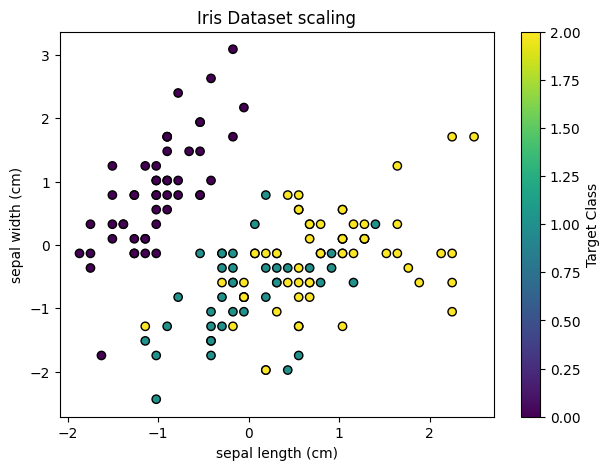

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(iris_scaler[:,0], iris_scaler[:,1], c=y_iris, cmap='viridis', edgecolor='k')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title('Iris Dataset scaling')
plt.colorbar(label='Target Class')
plt.show()

## Apply PCA reduce dimension form 4 ▶ 2 dimension

In [ ]:
pca = PCA(n_components=2)
iris_pca = pca.fit_transform(iris_scaler)

print("Transformed shape:", iris_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)

Transformed shape: (150, 2)
Explained variance ratio: [0.72962445 0.22850762]


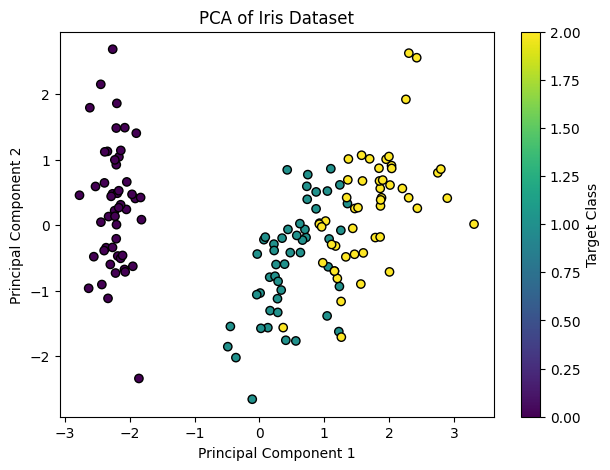

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(iris_pca[:,0], iris_pca[:,1], c=y_iris, cmap='viridis', edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.colorbar(label='Target Class')
plt.show()

## 3.2 t-SNE (t-distributed Stochastic Neighbor Embedding)
เป็นวิธีการทำ Dimensionality Reduction แบบ None-linear
> t-SNE จะ จัดกลุ่มข้อมูลที่คล้ายกันให้อยู่ใกล้กัน

> ใช้สำหรับ visualization ของข้อมูลหลายมิติใน 2D หรือ 3D

> เหมาะกับการสำรวจข้อมูล (data exploration)

> ไม่เหมาะกับการนำไปใช้ในการทำนาย (เพราะไม่สามารถ invert กลับได้)


---



## 3.2 t-SNE (t-distributed Stochastic Neighbor Embedding)
It is Dimensionality Reduction in None-linear
> t-SNE will try to group likely data to be near each other

> use for visualization data that contain many dimensions (e.g. 4+ dimensions) into 2D or 3D.

> suit for task like data exploration or data visialization

> not suit for using in reduced data before feeding to training ML (becasue each point in t-SNE we cann't reconstruct back into original set of dimensions due to it's stocastic method)

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(iris_scaler)

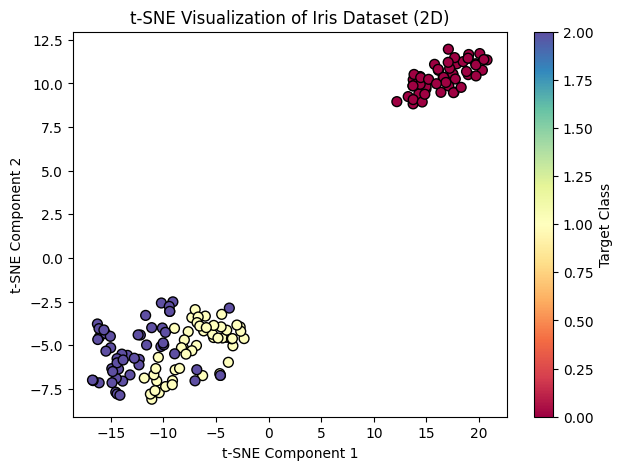

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_iris, cmap='Spectral', edgecolor='k', s=50)
plt.title('t-SNE Visualization of Iris Dataset (2D)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(label='Target Class')
plt.show()

# **4. Imbalanced Data**
Imbalanced Dataset คือ ข้อมูลที่ “**สัดส่วนของแต่ละ class ไม่เท่ากัน**”

เช่น Class 0 = 95%, Class 1 = 5% → โมเดลจะเรียนรู้ให้ทำนาย Class 0 เกือบตลอดเวลา
เพราะ **accuracy สูง ถึง 95%** แต่จริง ๆ แล้ว **performance แย่** สำหรับ class ที่น้อยกว่าโมเดลจะทำนายไม่ถูก

**ตัวอย่างปัญหา**
เช่น การตรวจโรค, การทุจริต, การตรวจ defect ในภาพ

Normal class (negative) มีเยอะ

Abnormal class (positive) มีน้อยมาก

ถ้าโมเดลเดาว่า “ทุกอันคือปกติ” → Accuracy = สูง
แต่ Recall ของ class abnormal = 0 ❌

**ผลลัพธ์ที่ดีควรดูจาก F1-score, Recall, AUC (ไม่ใช่ Accuracy อย่างเดียว)**


---


Imbalanced Dataset is the dataset that “**amount of data in each class is not equal**”

E.X. Class 0 = 95%, Class 1 = 5% → Model is goint to be trained to predict Class 0 almost all the time.
because in this way, model will give **high accuracy to 95%**, but actually our model **perform not good** since it cann't predict Class1

**Example of scenarios that can occurs Imbalanced Dataset**
เช่น diagnose in madical, detecting corruption, detecting defect in image

you can notice that typically:   

Volume of normal class (negative) is much more than volumn of Abnormal class (positive)

if model behave to predict in the way like **"everything is normal (be negative)"** → still make **High Accuracy**
but some indicators like Recall of Abnormal class = 0 ❌

**Thus inspecting performance of model, we should also use another indicators like F1-score, Recall, AUC (not just Accuracy)**

## 4.1 SMOTE (Synthetic Minority Oversampling Technique)

เทคนิคนี้ **สร้างข้อมูลใหม่ของฝั่ง class ที่มีข้อมูลน้อย** โดยการ interpolate ระหว่างเพื่อนบ้านใกล้เคียง


---


This technique creates new data in less side by interpoloting between neighbor data.

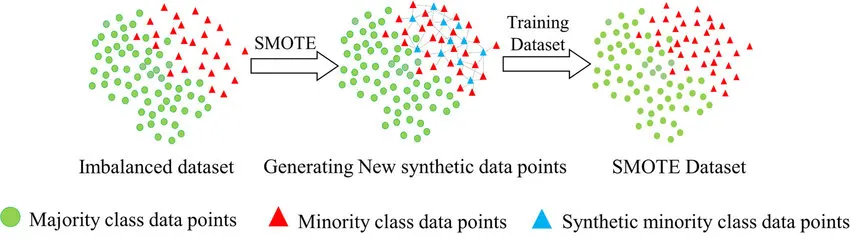

ref: https://pub.aimind.so/synthetic-minority-over-sampling-technique-smote-empowering-ai-through-imbalanced-data-handling-d86f4de32ea3

In [ ]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt

### Making Imbalanced Dataset

In [ ]:
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    weights=[0.9, 0.1],
    random_state=42
)

In [ ]:
print("Before SMOTE:", Counter(y))

Before SMOTE: Counter({np.int64(0): 447, np.int64(1): 53})


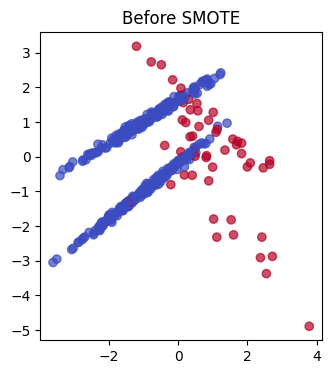

In [ ]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Before SMOTE")
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', alpha=0.7)
plt.show()

In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
print("After SMOTE:", Counter(y_resampled))

After SMOTE: Counter({np.int64(0): 447, np.int64(1): 447})


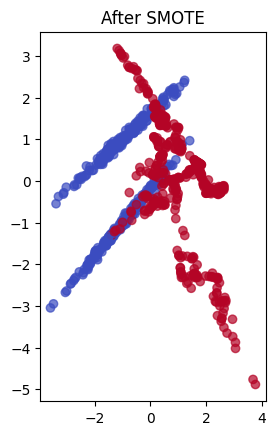

ก่อน SOMTE -> class 0 มากกว่า class 1 มาก
หลัง SMOTE -> ทั้งสอง class มีจำนวนใกล้เคียงกัน


In [ ]:
plt.subplot(1,2,2)
plt.title("After SMOTE")
plt.scatter(X_resampled[:,0], X_resampled[:,1], c=y_resampled, cmap='coolwarm', alpha=0.7)
plt.show()

print("before SOMTE -> class 0 is much more than class 1 ")
print("after SMOTE -> both class have the same amount")

## 4.2 Change Class Weight of model

ไม่ต้องเปลี่ยนข้อมูล แต่ให้ “**เพิ่มความสำคัญ**” ให้ class ที่น้อยกว่า
โดยใช้ parameter class_weight='balanced'


---


This method is not about adding more dataset in less side, but fix problem by give more important in the minor class by set the parameter class_weight='balanced'.    

Giving more important in the minor class by adjust loss function to punish model more harder when model predict the minor class wrong.
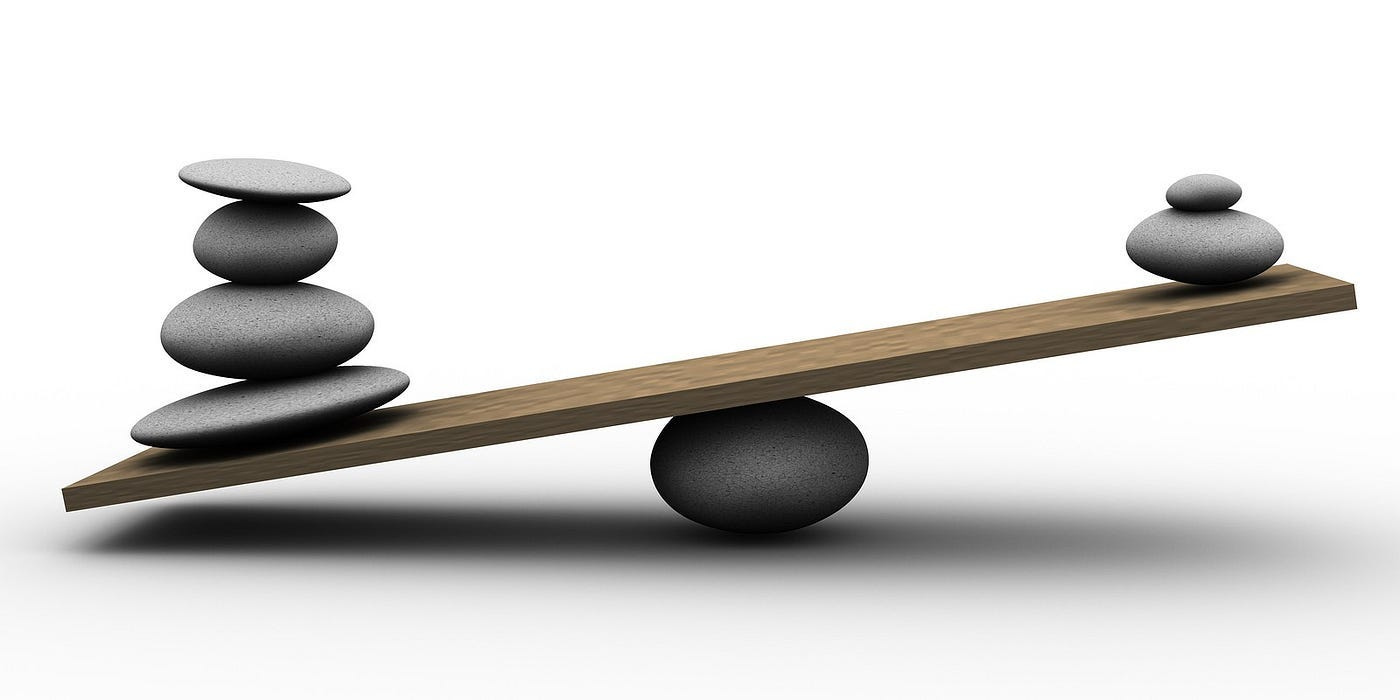

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Normal model training case (no using class weight)

In [ ]:
model_normal = LogisticRegression()
model_normal.fit(X_train, y_train)
y_pred_normal = model_normal.predict(X_test)

print("Without class_weight:")
print(classification_report(y_test, y_pred_normal))

Without class_weight:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       138
           1       1.00      0.50      0.67        12

    accuracy                           0.96       150
   macro avg       0.98      0.75      0.82       150
weighted avg       0.96      0.96      0.95       150



## Training model by using class_weight='balanced'

In [ ]:
model_weighted = LogisticRegression(class_weight='balanced')
model_weighted.fit(X_train, y_train)
y_pred_weighted = model_weighted.predict(X_test)

print("\nWith class_weight='balanced':")
print(classification_report(y_test, y_pred_weighted))
print("โมเดลที่ใช้ class_weight=balanced → มี recall ของ minority class ดีขึ้น \n Accuracy อาจลดลงเล็กน้อย แต่โมเดลยุติธรรมมากขึ้น")


With class_weight='balanced':
              precision    recall  f1-score   support

           0       0.97      0.83      0.89       138
           1       0.27      0.75      0.40        12

    accuracy                           0.82       150
   macro avg       0.62      0.79      0.65       150
weighted avg       0.92      0.82      0.85       150

โมเดลที่ใช้ class_weight=balanced → มี recall ของ minority class ดีขึ้น 
 Accuracy อาจลดลงเล็กน้อย แต่โมเดลยุติธรรมมากขึ้น


-----
# HW2_4: The Basis of Feature Engineering







ข้อมูลการซื้อขายและประเมินโดยลูกค้าเก็บมาแบบหยาบๆตามตัวอย่างข้างใต้\
The data about transaction and sentiment analysis were accumulated roughly as table below.

|Record ID|Customer Name|Product Category|Purchase Price (USD)|Review Score (1-5)|Subscription Status|Transaction Date (MM-DD-YYYY)|
|-|-|-|-|-|-|-|
|A-001|Alice C. Johnson|Electronics|150.00 USD|4/5|Active|2024-11-25|10:30:00|
|A-002|Bob S. Smith|Home Goods|45.99 USD|5/5|TRUE|11/26/2024 14:00|
|A-003|charlie brown|Books & Media|35.99 USD|5|Active|26-Nov-24 16:00|
|A-004|Alice C. Johnson|electronics|149.99|-1|FALSE|2024/11/27 10:00AM|
|A-005|Diana Miller|Clothing|55|3.5|Active|"Nov 27| 2024"|
|A-006|Bob S. Smith|Home goods|45.99|5/5|TRUE|14:00 2024-11-26|
|A-007|Eve Davis|Books & media|80|2|OFF|2024-11-28|
|A-008|Frank White|Food/Beverage|15|10|Active|28.11.2024|
|A-009|GINA Harris|CLOTHING|55.00 USD|2.5/5|FALSE|NULL|
|A-010|H. Jones|Food/Beverage|25.5|4|ACTIVE|29-Nov-2024|

พยายามทำความสะอาดและจัดการข้อมูลให้พร้อมใช้งานสำหรับแบบจำลองการเรียนรู้ (วิธีการวิศวกรรมคุณลักษณะเลือกใช้ด้วยตัวเอง)\
Try to clean and manipulate to make it available for a learning model (feature engineering methods depend on your own implementation).